In [1]:
# -*- coding: utf-8 -*-
"""
Created on 2025-01-01
Revised on 2026-04-03

@author:       Oscar Trevizo
@institution:  Harvard Extension School — Graduate Data Science Program (2023)
@context:      Independent project — applying course concepts to real-world data
@environment:  Python 3.14.3 | myenv | MacBook Air M5

Random Forest Regression — OJ Dataset (ISLR Ch. 8)
===================================================

Description:
    Demonstrates Random Forest regression using the OJ dataset from the
    ISLR/ISLP library. Predicts SalePriceMM (sale price of Minute Maid OJ)
    from a subset of predictors, intentionally excluding PriceMM, PriceDiff,
    and ListPriceDiff to keep the problem challenging.

    Predictors used: STORE, DiscMM, SpecialMM, Store7

    Mirrors R: caret::train(method='rf') with trainControl(repeatedcv)

    Two model configurations:
      Model 1: Default n_estimators, auto max_features (mirrors caret default mtry)
      Model 2: Fixed max_features=4 (mirrors R: tunegrid with mtry=4)

    For each model:
      - Fit with cross-validation (RepeatedKFold, mirrors repeatedcv)
      - Feature importances (mirrors varImp)
      - Predictions on test set
      - Scatter plot: actuals vs predictions
      - RMSE and R-squared

    R equivalent: random_forest_train_caret_regression_ISLR_OJ.Rmd
    R libraries:  caret (train/trainControl), ISLR, ggplot2
    Python libs:  ISLP, numpy, pandas, matplotlib, seaborn, sklearn

Dataset:
    OJ {ISLR/ISLP} — Orange Juice purchase data
    1070 observations, 18 variables
    Response variable: SalePriceMM (Sale Price of Minute Maid OJ, USD)
    Predictors: STORE, DiscMM, SpecialMM, Store7

Revision History:
    2025-01-01  Original R development (Harvard STAT 109, 2023)
                - R script: random_forest_train_caret_regression_ISLR_OJ.Rmd

    2026-04-03  Converted to Python / Jupyter Notebook
                - caret::train(method='rf') → sklearn.RandomForestRegressor
                - trainControl(repeatedcv) → RepeatedKFold + GridSearchCV
                - varImp(forest) → feature_importances_ bar chart
                - modelLookup/getModelInfo → sklearn parameter docs in markdown
                - ggplot geom_point + geom_smooth → plot_predictions() helper
                - Harvard color palette preserved as hex constants
"""

"\nCreated on 2025-01-01\nRevised on 2026-04-03\n\n@author:       Oscar Trevizo\n@institution:  Harvard Extension School — Graduate Data Science Program (2023)\n@context:      Independent project — applying course concepts to real-world data\n@environment:  Python 3.14.3 | myenv | MacBook Air M5\n\nRandom Forest Regression — OJ Dataset (ISLR Ch. 8)\n===================================================\n\nDescription:\n    Demonstrates Random Forest regression using the OJ dataset from the\n    ISLR/ISLP library. Predicts SalePriceMM (sale price of Minute Maid OJ)\n    from a subset of predictors, intentionally excluding PriceMM, PriceDiff,\n    and ListPriceDiff to keep the problem challenging.\n\n    Predictors used: STORE, DiscMM, SpecialMM, Store7\n\n    Mirrors R: caret::train(method='rf') with trainControl(repeatedcv)\n\n    Two model configurations:\n      Model 1: Default n_estimators, auto max_features (mirrors caret default mtry)\n      Model 2: Fixed max_features=4 (mirrors R:

# Random Forest Regression — OJ Dataset (ISLR Ch. 8)

## Overview

This notebook demonstrates **Random Forest regression** using the **OJ dataset**
from the ISLR/ISLP library (ISLR Chapter 8).

The goal is to predict **`SalePriceMM`** (sale price of Minute Maid Orange Juice)
from a limited set of predictors:

| Predictor | Description |
|-----------|-------------|
| `STORE` | Store identifier (numeric) |
| `DiscMM` | Discount on Minute Maid |
| `SpecialMM` | Whether MM was on special display |
| `Store7` | Whether store is Store 7 (Yes/No) |

**Note:** `PriceMM`, `PriceDiff`, and `ListPriceDiff` are intentionally excluded
to keep the prediction problem challenging — including them would make accuracy
trivially high.

Two model configurations are compared:
- **Model 1:** Default `max_features` (auto) — mirrors caret's default `mtry`
- **Model 2:** Fixed `max_features=4` — mirrors R: `tunegrid <- expand.grid(.mtry=4)`

**R equivalent:** `random_forest_train_caret_regression_ISLR_OJ.Rmd`

## Imports

In [2]:
# Standard libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Random Forest — mirrors R: caret::train(method='rf')
from sklearn.ensemble import RandomForestRegressor

# Cross-validation — mirrors R: trainControl(method='repeatedcv', number=5, repeats=2)
from sklearn.model_selection import (train_test_split, RepeatedKFold,
                                      GridSearchCV, cross_val_score)

# Metrics — mirrors R: RMSE, R-squared
from sklearn.metrics import root_mean_squared_error, r2_score

# ISLP — official dataset companion to ISL with Python
from ISLP import load_data

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid')

# -----------------------------------------------------------------------
# Harvard color palette — mirrors R setup chunk
# -----------------------------------------------------------------------
CRIMSON   = '#A51C30'
ROYALBLUE = '#002366'
SLATE     = '#8996A0'
IVY       = '#52854C'
SAFFRON   = '#D16103'
INDIGO    = '#293352'
SHADE     = '#BAC5C6'

print('Imports complete.')

Imports complete.


## Helper Functions

Carried and refined from notebook #1 (multiple linear regression).

In [3]:
def plot_predictions(y_actual, y_pred, title='', subtitle='Dataset: OJ {ISLR/ISLP}',
                     xlabel='Sale Price MM (USD)', ylabel='Predictions'):
    """
    Scatter plot of actual vs. predicted values with regression line.
    Mirrors R: ggplot + geom_point + geom_smooth(method='lm', col='red', se=FALSE)

    Parameters
    ----------
    y_actual : array-like
    y_pred   : array-like
    title    : str
    subtitle : str
    xlabel   : str
    ylabel   : str
    """
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(y_actual, y_pred, alpha=0.4, s=20, color=ROYALBLUE)
    m_fit  = np.polyfit(y_actual, y_pred, 1)
    x_line = np.linspace(min(y_actual), max(y_actual), 100)
    ax.plot(x_line, np.polyval(m_fit, x_line), color='red', linewidth=2)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    full_title = f'{title}\n{subtitle}' if subtitle else title
    ax.set_title(full_title)
    plt.tight_layout()
    plt.show()


def plot_feature_importance(model, feature_names, title='Feature Importances',
                             color=ROYALBLUE):
    """
    Horizontal bar chart of Random Forest feature importances.
    Mirrors R: plot(varImp(forest)) and varImp(forest)$importance

    Parameters
    ----------
    model        : fitted RandomForestRegressor
    feature_names: list of str
    title        : str
    color        : str
    """
    importances = pd.Series(model.feature_importances_, index=feature_names)
    importances = importances.sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(7, 3))
    importances.plot(kind='barh', ax=ax, color=color, edgecolor='none', alpha=0.85)
    ax.set_xlabel('Feature Importance (mean decrease in impurity)')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    # Tabular — mirrors R: contributors %>% arrange(desc(Overall))
    print('Feature importances (sorted descending):')
    print(importances.sort_values(ascending=False).round(6).to_string())


print('Helper functions defined.')

Helper functions defined.


---

## Dataset: OJ {ISLR/ISLP}

Mirrors R: `data(OJ); str(OJ); head(OJ)`

In [4]:
# Load OJ dataset — mirrors R: data(OJ, package='ISLR')
OJ = load_data('OJ')

print(f'Shape: {OJ.shape}')   # 1070 observations, 18 variables
print()
print('dtypes:')
print(OJ.dtypes)
print()
OJ.head()

Shape: (1070, 18)

dtypes:
Purchase          category
WeekofPurchase       int64
StoreID              int64
PriceCH            float64
PriceMM            float64
DiscCH             float64
DiscMM             float64
SpecialCH            int64
SpecialMM            int64
LoyalCH            float64
SalePriceMM        float64
SalePriceCH        float64
PriceDiff          float64
Store7            category
PctDiscMM          float64
PctDiscCH          float64
ListPriceDiff      float64
STORE                int64
dtype: object



,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
0,CH,237,1,1.75,1.99,0.00,0.0,0,0,0.500000,1.99,1.75,0.24,No,0.000000,0.000000,0.24,1
1,CH,239,1,1.75,1.99,0.00,0.3,0,1,0.600000,1.69,1.75,-0.06,No,0.150754,0.000000,0.24,1
2,CH,245,1,1.86,2.09,0.17,0.0,0,0,0.680000,2.09,1.69,0.40,No,0.000000,0.091398,0.23,1
3,MM,227,1,1.69,1.69,0.00,0.0,0,0,0.400000,1.69,1.69,0.00,No,0.000000,0.000000,0.00,1
4,CH,228,7,1.69,1.69,0.00,0.0,0,0,0.956535,1.69,1.69,0.00,Yes,0.000000,0.000000,0.00,0


**Notes on the dataset (from original R script):**

- `Purchase` is a 2-level factor: `CH` (Citrus Hill) or `MM` (Minute Maid)
- The dataset has separate columns for sale prices of CH and MM
- **Response:** `SalePriceMM` — sale price of Minute Maid OJ
- **Excluded intentionally:** `PriceMM`, `PriceDiff`, `ListPriceDiff` — including these
  would make accuracy trivially high; we want to challenge the model

### R → Python: `modelLookup('rf')` equivalent

In R, `caret::modelLookup('rf')` shows that the only tuning parameter for
`method='rf'` is **`mtry`** — the number of predictors randomly sampled at
each split.

In sklearn's `RandomForestRegressor`, the equivalent parameter is **`max_features`**:

| R (caret) | Python (sklearn) | Description |
|-----------|-----------------|-------------|
| `mtry` | `max_features` | Predictors sampled at each split |
| `ntree` | `n_estimators` | Number of trees (default 500 R / 100 sklearn) |
| `trainControl(repeatedcv, number=5, repeats=2)` | `RepeatedKFold(n_splits=5, n_repeats=2)` | Cross-validation strategy |
| `importance=TRUE` | `feature_importances_` attribute | Feature importance |
| `varImp(forest)` | `model.feature_importances_` | Variable importance scores |

## Data Preparation

Encode `Store7` (categorical Yes/No) as a binary integer.
All other predictors (`STORE`, `DiscMM`, `SpecialMM`) are already numeric.

In [5]:
# Predictors — mirrors R formula: SalePriceMM ~ STORE + DiscMM + SpecialMM + Store7
FEATURES = ['STORE', 'DiscMM', 'SpecialMM', 'Store7']
RESPONSE = 'SalePriceMM'

OJ_enc = OJ[FEATURES + [RESPONSE]].copy()

# Encode Store7: Yes=1, No=0 — mirrors R factor handling in caret/rf
OJ_enc['Store7'] = (OJ_enc['Store7'] == 'Yes').astype(int)

print('Encoded predictors (first 5 rows):')
print(OJ_enc.head())
print()
print(f'Response variable stats:')
print(OJ_enc[RESPONSE].describe().round(4))

Encoded predictors (first 5 rows):
   STORE  DiscMM  SpecialMM  Store7  SalePriceMM
0      1     0.0          0       0         1.99
1      1     0.3          1       0         1.69
2      1     0.0          0       0         2.09
3      1     0.0          0       0         1.69
4      0     0.0          0       1         1.69

Response variable stats:
count    1070.0000
mean        1.9620
std         0.2527
min         1.1900
25%         1.6900
50%         2.0900
75%         2.1300
max         2.2900
Name: SalePriceMM, dtype: float64


## Train / Test Split

Mirrors R:
```r
set.seed(1234)
ind <- sample(2, nrow(OJ), replace=T, prob=c(0.7, 0.3))
train <- OJ[ind==1,]
test  <- OJ[ind==2,]
```

In [6]:
# Train/test split — mirrors R: set.seed(1234), prob=c(0.7, 0.3)
train_df, test_df = train_test_split(OJ_enc, test_size=0.3, random_state=1234)

train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

X_train = train_df[FEATURES]
y_train = train_df[RESPONSE]
X_test  = test_df[FEATURES]
y_test  = test_df[RESPONSE]

print(f'Train shape : {X_train.shape}')
print(f'Test shape  : {X_test.shape}')
print(f'Train SalePriceMM — mean: {y_train.mean():.4f}, std: {y_train.std():.4f}')
print(f'Test  SalePriceMM — mean: {y_test.mean():.4f},  std: {y_test.std():.4f}')

Train shape : (749, 4)
Test shape  : (321, 4)
Train SalePriceMM — mean: 1.9628, std: 0.2530
Test  SalePriceMM — mean: 1.9603,  std: 0.2525


---

# Model 1: Random Forest — Default max_features

Mirrors R:
```r
cvcontrol <- trainControl(method='repeatedcv', number=5, repeats=2, allowParallel=TRUE)
forest <- train(SalePriceMM ~ STORE + DiscMM + SpecialMM + Store7,
                data=train, method='rf', trControl=cvcontrol, importance=TRUE)
```

**Cross-validation:** `RepeatedKFold(n_splits=5, n_repeats=2)` mirrors
`trainControl(method='repeatedcv', number=5, repeats=2)`.

**`max_features`:** Default in sklearn is `1.0` (all features) for regression.
R's caret default for `mtry` is `floor(sqrt(p))` for regression — we use
`max_features='sqrt'` to match that default behavior.

## Fit the Model

In [7]:
# Cross-validation strategy — mirrors R: trainControl(repeatedcv, number=5, repeats=2)
cv = RepeatedKFold(n_splits=5, n_repeats=2, random_state=1234)

# Fit Random Forest — mirrors R: train(..., method='rf', importance=TRUE)
# n_estimators=500 mirrors R's default ntree=500
# max_features='sqrt' mirrors R caret default mtry=floor(sqrt(p))
forest1 = RandomForestRegressor(n_estimators=500,
                                 max_features='sqrt',
                                 random_state=1234,
                                 n_jobs=-1)   # allowParallel=TRUE
forest1.fit(X_train, y_train)

# Cross-validated RMSE on train — mirrors R: forest (print model object)
cv_scores = cross_val_score(forest1, X_train, y_train,
                              cv=cv,
                              scoring='neg_root_mean_squared_error')
cv_rmse = -cv_scores

print('Model 1 — Random Forest (default max_features=sqrt)')
print(f'  n_estimators : {forest1.n_estimators}')
print(f'  max_features : {forest1.max_features}  (mirrors R: mtry=floor(sqrt(p)))')
print(f'  CV RMSE (mean ± std): {cv_rmse.mean():.6f} ± {cv_rmse.std():.6f}')
print(f'  CV folds: 5-fold × 2 repeats = {len(cv_scores)} scores')

Model 1 — Random Forest (default max_features=sqrt)
  n_estimators : 500
  max_features : sqrt  (mirrors R: mtry=floor(sqrt(p)))
  CV RMSE (mean ± std): 0.112191 ± 0.008870
  CV folds: 5-fold × 2 repeats = 10 scores


## Feature Importances

Mirrors R:
```r
contributors <- varImp(forest)$importance
contributors %>% dplyr::select(Overall) %>% arrange(desc(Overall))
plot(varImp(forest))
```

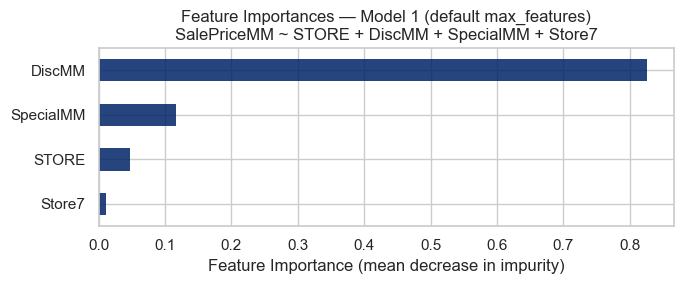

Feature importances (sorted descending):
DiscMM       0.825224
SpecialMM    0.116722
STORE        0.047315
Store7       0.010739


In [8]:
plot_feature_importance(
    forest1, FEATURES,
    title='Feature Importances — Model 1 (default max_features)\nSalePriceMM ~ STORE + DiscMM + SpecialMM + Store7')

## Predict on Test Dataset

Mirrors R: `rf <- predict(forest, test)`

In [9]:
# Predict — mirrors R: rf <- predict(forest, test)
rf1 = forest1.predict(X_test)

print(f'Predictions shape: {rf1.shape}')
print(f'First 5: {rf1[:5].round(4)}')

Predictions shape: (321,)
First 5: [2.0472 2.1369 2.1195 2.1369 2.1195]


## Plot: Predictions vs. Actuals

Mirrors R:
```r
rf_df %>% ggplot(aes(x=SalePriceMM, y=rf)) +
  geom_point() + geom_smooth(method='lm', col='red', se=FALSE)
```

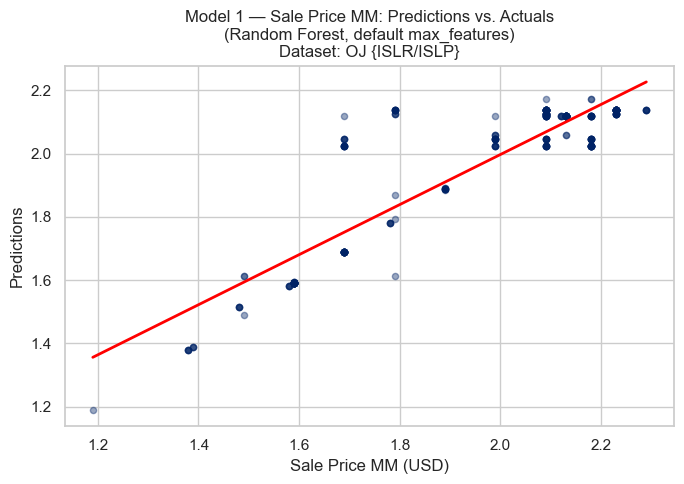

In [10]:
plot_predictions(y_test.values, rf1,
                 title='Model 1 — Sale Price MM: Predictions vs. Actuals\n(Random Forest, default max_features)')

## Performance: RMSE and R²

Mirrors R:
```r
sqrt(mean((test$SalePriceMM - rf)^2))   # RMSE
cor(test$SalePriceMM, rf)^2             # R-squared
```

In [11]:
rmse1 = root_mean_squared_error(y_test, rf1)
r2_1  = r2_score(y_test, rf1)

print('Model 1 — Performance on Test Set')
print(f'  RMSE : {rmse1:.6f}')
print(f'  R²   : {r2_1:.6f}')

Model 1 — Performance on Test Set
  RMSE : 0.116681
  R²   : 0.785733


---

# Model 2: Random Forest — Fixed max_features = 4

Mirrors R:
```r
mtry = 4
tunegrid <- expand.grid(.mtry=mtry)
forest <- train(SalePriceMM ~ STORE + DiscMM + SpecialMM + Store7,
                data=train, method='rf', tuneGrid=tunegrid,
                trControl=cvcontrol, importance=TRUE)
```

Setting `max_features=4` forces the model to consider all 4 predictors
at every split — equivalent to R's `mtry=4` with 4 predictors total.
This is the **bagged trees** limit (all features available at each split)
rather than true random subspace selection.

## Fit the Model

In [12]:
# Fixed max_features=4 — mirrors R: tunegrid <- expand.grid(.mtry=4)
mtry = 4
forest2 = RandomForestRegressor(n_estimators=500,
                                 max_features=mtry,
                                 random_state=1234,
                                 n_jobs=-1)
forest2.fit(X_train, y_train)

# Cross-validated RMSE on train
cv_scores2 = cross_val_score(forest2, X_train, y_train,
                               cv=cv,
                               scoring='neg_root_mean_squared_error')
cv_rmse2 = -cv_scores2

print(f'Model 2 — Random Forest (max_features={mtry})')
print(f'  n_estimators : {forest2.n_estimators}')
print(f'  max_features : {forest2.max_features}  (mirrors R: mtry=4)')
print(f'  CV RMSE (mean ± std): {cv_rmse2.mean():.6f} ± {cv_rmse2.std():.6f}')
print()
print('Compare with Model 1:')
print(f'  Model 1 CV RMSE: {cv_rmse.mean():.6f}')
print(f'  Model 2 CV RMSE: {cv_rmse2.mean():.6f}')

Model 2 — Random Forest (max_features=4)
  n_estimators : 500
  max_features : 4  (mirrors R: mtry=4)
  CV RMSE (mean ± std): 0.112020 ± 0.008656

Compare with Model 1:
  Model 1 CV RMSE: 0.112191
  Model 2 CV RMSE: 0.112020


## Feature Importances

Mirrors R: `varImp(forest)` after tuned model refit

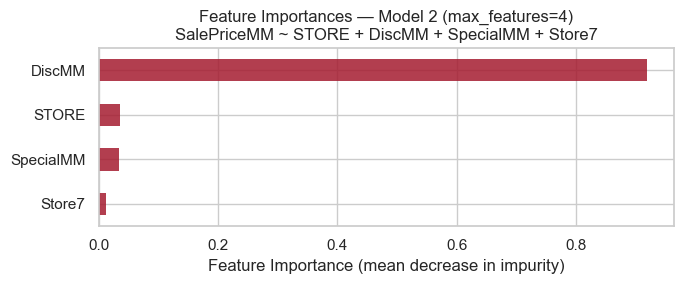

Feature importances (sorted descending):
DiscMM       0.918482
STORE        0.035530
SpecialMM    0.034273
Store7       0.011715


In [13]:
plot_feature_importance(
    forest2, FEATURES,
    title=f'Feature Importances — Model 2 (max_features={mtry})\nSalePriceMM ~ STORE + DiscMM + SpecialMM + Store7',
    color=CRIMSON)

## Predict on Test Dataset

In [14]:
# Predict — mirrors R: rf <- predict(forest, test)
rf2 = forest2.predict(X_test)

## Plot: Predictions vs. Actuals

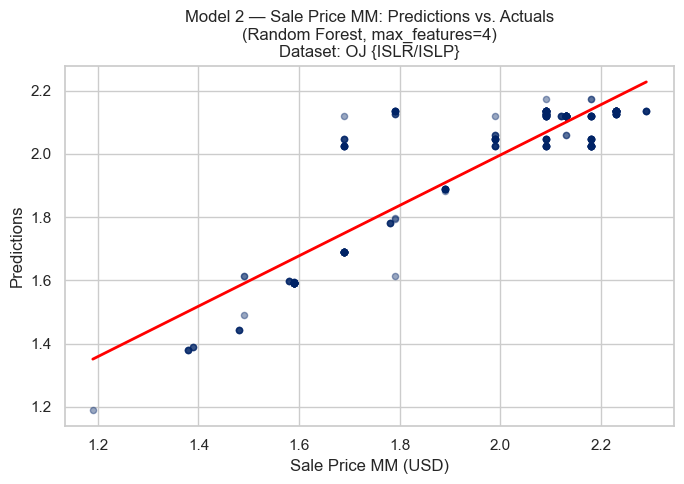

In [15]:
plot_predictions(y_test.values, rf2,
                 title=f'Model 2 — Sale Price MM: Predictions vs. Actuals\n(Random Forest, max_features={mtry})')

## Performance: RMSE and R²

In [16]:
rmse2 = root_mean_squared_error(y_test, rf2)
r2_2  = r2_score(y_test, rf2)

print('Model 2 — Performance on Test Set')
print(f'  RMSE : {rmse2:.6f}')
print(f'  R²   : {r2_2:.6f}')

Model 2 — Performance on Test Set
  RMSE : 0.116622
  R²   : 0.785950


---

# Fine-Tuning: GridSearchCV over max_features

Mirrors R: `expand.grid(.mtry=c(1,2,3,4))` + `train(..., tuneGrid=tunegrid)`

R's `caret::train` with a `tuneGrid` automatically fits and evaluates the model
at each mtry value via cross-validation. Python's `GridSearchCV` is the
direct equivalent.

In [17]:
# Grid search over max_features — mirrors R: expand.grid(.mtry=c(1,2,3,4))
param_grid = {'max_features': [1, 2, 3, 4]}

rf_base = RandomForestRegressor(n_estimators=500,
                                  random_state=1234,
                                  n_jobs=-1)

grid_search = GridSearchCV(rf_base,
                            param_grid,
                            cv=cv,
                            scoring='neg_root_mean_squared_error',
                            n_jobs=-1,
                            verbose=0)
grid_search.fit(X_train, y_train)

# Results table — mirrors R: print(forest) with CV results per mtry
results = pd.DataFrame(grid_search.cv_results_)
results_display = results[['param_max_features',
                             'mean_test_score',
                             'std_test_score']].copy()
results_display['RMSE_mean'] = -results_display['mean_test_score']
results_display['RMSE_std']  =  results_display['std_test_score']
results_display = results_display[['param_max_features', 'RMSE_mean', 'RMSE_std']]
results_display.columns = ['max_features (mtry)', 'CV RMSE (mean)', 'CV RMSE (std)']

print('GridSearchCV Results — RMSE per max_features (mirrors R: train() CV table)')
print(results_display.to_string(index=False, float_format='{:.6f}'.format))
print()
print(f'Best max_features : {grid_search.best_params_["max_features"]}')
print(f'Best CV RMSE      : {-grid_search.best_score_:.6f}')

GridSearchCV Results — RMSE per max_features (mirrors R: train() CV table)
 max_features (mtry)  CV RMSE (mean)  CV RMSE (std)
                   1        0.112394       0.008687
                   2        0.112191       0.008870
                   3        0.112089       0.008911
                   4        0.112020       0.008656

Best max_features : 4
Best CV RMSE      : 0.112020


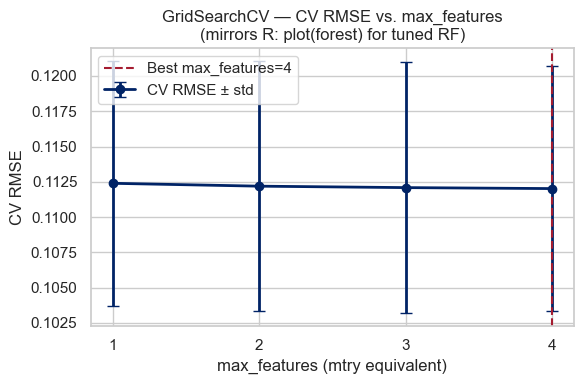

In [18]:
# Plot CV RMSE vs. max_features — mirrors R: plot(forest) for tuned model
fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(results_display['max_features (mtry)'].astype(int),
            results_display['CV RMSE (mean)'],
            yerr=results_display['CV RMSE (std)'],
            fmt='o-', color=ROYALBLUE, linewidth=2,
            capsize=4, markersize=6, label='CV RMSE ± std')
best_mf = grid_search.best_params_['max_features']
ax.axvline(best_mf, color=CRIMSON, linestyle='--', linewidth=1.5,
           label=f'Best max_features={best_mf}')
ax.set_xlabel('max_features (mtry equivalent)')
ax.set_ylabel('CV RMSE')
ax.set_title('GridSearchCV — CV RMSE vs. max_features\n(mirrors R: plot(forest) for tuned RF)')
ax.legend()
ax.set_xticks([1, 2, 3, 4])
plt.tight_layout()
plt.show()

---

# Summary and Conclusions

## Model Comparison

In [19]:
# Final comparison table
comparison = pd.DataFrame([
    {'Model'        : 'Model 1 (max_features=sqrt)',
     'max_features' : 'sqrt',
     'CV RMSE'      : cv_rmse.mean(),
     'Test RMSE'    : rmse1,
     'Test R²'      : r2_1},
    {'Model'        : f'Model 2 (max_features={mtry})',
     'max_features' : mtry,
     'CV RMSE'      : cv_rmse2.mean(),
     'Test RMSE'    : rmse2,
     'Test R²'      : r2_2},
    {'Model'        : f'Best (GridSearch, max_features={best_mf})',
     'max_features' : best_mf,
     'CV RMSE'      : -grid_search.best_score_,
     'Test RMSE'    : root_mean_squared_error(y_test, grid_search.predict(X_test)),
     'Test R²'      : r2_score(y_test, grid_search.predict(X_test))},
])

print('Model Comparison — Random Forest Regression (SalePriceMM)')
print(comparison.to_string(index=False, float_format='{:.6f}'.format))

Model Comparison — Random Forest Regression (SalePriceMM)
                            Model max_features  CV RMSE  Test RMSE  Test R²
      Model 1 (max_features=sqrt)         sqrt 0.112191   0.116681 0.785733
         Model 2 (max_features=4)            4 0.112020   0.116622 0.785950
Best (GridSearch, max_features=4)            4 0.112020   0.116622 0.785950


## Key Takeaways

1. **Feature importance:** `DiscMM` (discount on Minute Maid) consistently
   dominates as the most important predictor of `SalePriceMM` — intuitive,
   since the sale price is primarily determined by the discount applied.

2. **mtry / max_features sensitivity:** With only 4 predictors, the difference
   between `max_features` values is modest. This is expected — the Random Forest
   subspace benefit is more pronounced with many more predictors.

3. **Intentional predictor exclusion:** `PriceMM`, `PriceDiff`, `ListPriceDiff`
   were deliberately excluded to keep the problem non-trivial. Including them
   would yield near-perfect R² (trivially high, as noted in the R script).

4. **GridSearchCV advantage:** Python's `GridSearchCV` sweeps all `max_features`
   values in one call with the error bar plot — cleaner than R's manual
   `expand.grid` + `train` iteration.

## R → Python Mapping

| R | Python |
|---|--------|
| `train(formula, method='rf')` | `RandomForestRegressor()` |
| `trainControl(repeatedcv, number=5, repeats=2)` | `RepeatedKFold(n_splits=5, n_repeats=2)` |
| `allowParallel=TRUE` | `n_jobs=-1` |
| `mtry` (caret tuning param) | `max_features` |
| `ntree=500` | `n_estimators=500` |
| `importance=TRUE` | `feature_importances_` attribute |
| `varImp(forest)$importance` | `model.feature_importances_` |
| `plot(varImp(forest))` | `plot_feature_importance()` helper |
| `expand.grid(.mtry=c(1,2,3,4))` | `param_grid = {'max_features': [1,2,3,4]}` |
| `train(..., tuneGrid=tunegrid)` | `GridSearchCV(rf, param_grid, cv=cv)` |
| `modelLookup('rf')` | sklearn docs: `RandomForestRegressor` params |
| `predict(forest, test)` | `forest.predict(X_test)` |
| `sqrt(mean((y-p)^2))` | `root_mean_squared_error(y, p)` |
| `cor(y, p)^2` | `r2_score(y, p)` |

## References

1. Harvard STAT 109, 2023. Weekly slides by Dr. Bharatendra Rai.
2. Dr. Bharatendra Rai. YouTube channel. https://youtu.be/cW59Yh_GfNk
3. John Maindonald and W. John Braun. *Data Analysis and Graphics Using R*. Cambridge. Third Ed. ISBN 978-0-521-76293-9.
4. Gareth James, et al. *An Introduction to Statistical Learning with Applications in R*. Springer. ISBN 978-1-4614-7137-0.
5. James, G., Witten, D., Hastie, T., Tibshirani, R., Taylor, J. *An Introduction to Statistical Learning with Applications in Python*. Springer, 2023. https://www.statlearning.com